In [2]:
# imports, package globals and the shared plotting helpers

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import PcmPy as pcm

import EFC_learningfMRI.globals as gl
import EFC_learningfMRI.util as ut 
import EFC_learningfMRI.vis  as vis 

warnings.filterwarnings('ignore')

Basis of this analysis: 
behavioral/force.run.wide.tsv

scripts.behavioral_summary.xxx ?? 
OR 
scripts.behavioral_summary('dddd') ?? 

which produces 

G_obs_raw.within_session.{sess}.force.{metric}.npy

In [3]:
# pick one example participant and list the chords they trained
sn     = 102                           # example participant
chords = ut.get_trained_and_untrained(sn)    # the 4 trained chords, then the 4 untrained ones
path   = os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}')

print(f'subj{sn}: trained {chords[:4]}, untrained {chords[4:]}')

subj102: trained ['22911', '11911', '21291', '12291'], untrained ['21911', '92122', '91211', '12129']


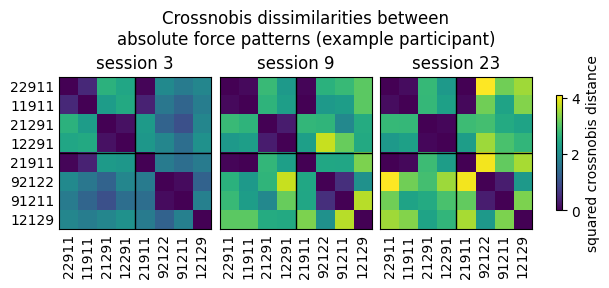

In [4]:
# example participant: dissimilarities between average absolute force patterns, one matrix per session

metric = 'abs'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

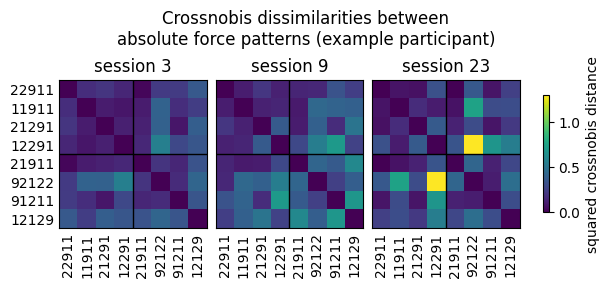

In [ ]:
# example participant: dissimilarities between absolute force derivative patterns, one matrix per session

metric = 'der'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

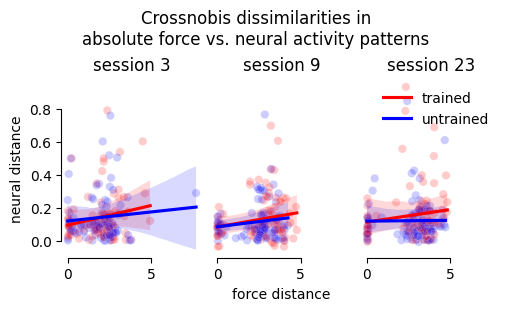

In [161]:
# load the force and neural dissimilarity dataframes, and plot neural against absolute force distances in M1

atlas = 'ROI'
H     = 'L'
roi   = 'M1'
glm   = 3

metric = 'abs'

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

force   = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, 'dissimilarity.within_session.force.tsv'), sep='\t')
force   = force[force.chord.isin(hue_order)] # exclude cross-set dissimilarities
force_m = force[force.metric == metric]

neural   = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
neural   = neural[neural.chord.isin(hue_order)]
neural_r = neural[(neural.Hem == H) & (neural.roi == roi)]

data = pd.merge(force_m, neural_r, on=['sn', 'session', 'pair', 'chord'], suffixes=('_force', '_neural'))

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5, 3), constrained_layout=True)

for s, sess in enumerate(gl.sessions):
    ax     = axs[s]
    data_s = data[data.session == sess]

    sb.scatterplot(data=data_s, ax=ax, x='crossnobis_force', y='crossnobis_neural',
                   hue='chord', hue_order=hue_order, palette=palette, legend=False, alpha=.2)
    sb.regplot(data=data_s[data_s.chord=='trained'], ax=ax, x='crossnobis_force', y='crossnobis_neural', scatter=False, units='sn', color=palette[0], label='trained')
    sb.regplot(data=data_s[data_s.chord=='untrained'], ax=ax, x='crossnobis_force', y='crossnobis_neural', scatter=False, units='sn', color=palette[1], label='untrained')

    ax.set_title(f'session {sess}')
    ax.set_xlabel(None)
    ax.set_ylabel('neural distance' if s == 0 else None)
    ax.tick_params(left=s==0)
    sb.despine(ax=ax, left=s>0, trim=True)

axs[-1].legend(frameon=False, loc='upper right')
axs[1].set_xlabel('force distance')
fig.suptitle('Crossnobis dissimilarities in\nabsolute force vs. neural activity patterns')

plt.show()

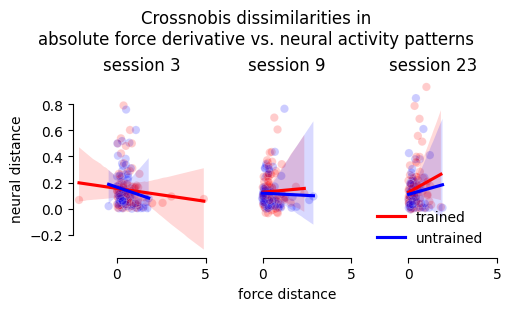

In [162]:
# neural against absolute force derivative distances in M1

metric = 'der'

force_m = force[force.metric == metric]

data = pd.merge(force_m, neural_r, on=['sn', 'session', 'pair', 'chord'], suffixes=('_force', '_neural'))

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5, 3), constrained_layout=True)

for s, sess in enumerate(gl.sessions):
    ax     = axs[s]
    data_s = data[data.session == sess]

    sb.scatterplot(data=data_s, ax=ax, x='crossnobis_force', y='crossnobis_neural',
                   hue='chord', hue_order=hue_order, palette=palette, legend=False, alpha=.2)
    sb.regplot(data=data_s[data_s.chord=='trained'], ax=ax, x='crossnobis_force', y='crossnobis_neural', scatter=False, units='sn', color=palette[0], label='trained')
    sb.regplot(data=data_s[data_s.chord=='untrained'], ax=ax, x='crossnobis_force', y='crossnobis_neural', scatter=False, units='sn', color=palette[1], label='untrained')

    ax.set_title(f'session {sess}')
    ax.tick_params(left=s==0)
    ax.set_xlabel(None)
    ax.set_ylabel('neural distance' if s == 0 else None)
    sb.despine(ax=ax, left=s>0, trim=True)

axs[-1].legend(frameon=False, loc='lower left')
axs[1].set_xlabel('force distance')
fig.suptitle('Crossnobis dissimilarities in\nabsolute force derivative vs. neural activity patterns')

plt.show()

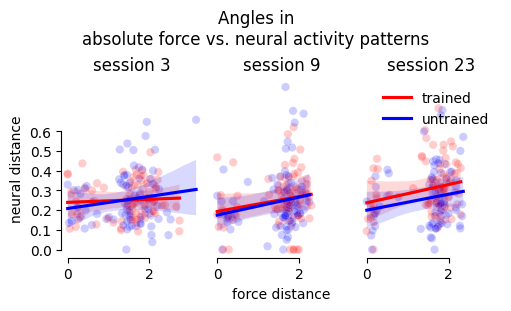

In [163]:
# neural against absolute force angles in M1

metric = 'abs'

force_m = force[force.chord.isin(hue_order) & (force.metric == metric)]

data = pd.merge(force_m, neural_r, on=['sn', 'session', 'pair', 'chord'], suffixes=('_force', '_neural'))

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5, 3), constrained_layout=True)

for s, sess in enumerate(gl.sessions):
    ax     = axs[s]
    data_s = data[data.session == sess]

    sb.scatterplot(data=data_s, ax=ax, x='theta_force', y='theta_neural',
                   hue='chord', hue_order=hue_order, palette=palette, legend=False, alpha=.2)
    sb.regplot(data=data_s[data_s.chord=='trained'], ax=ax, x='theta_force', y='theta_neural', scatter=False, units='sn', color=palette[0], label='trained')
    sb.regplot(data=data_s[data_s.chord=='untrained'], ax=ax, x='theta_force', y='theta_neural', scatter=False, units='sn', color=palette[1], label='untrained')

    ax.set_title(f'session {sess}')
    ax.set_xlabel(None)
    ax.set_ylabel('neural distance' if s == 0 else None)
    ax.tick_params(left=s==0)
    sb.despine(ax=ax, left=s>0, trim=True)

axs[-1].legend(frameon=False, loc='upper right')
axs[1].set_xlabel('force distance')
fig.suptitle('Angles in\nabsolute force vs. neural activity patterns')

plt.show()

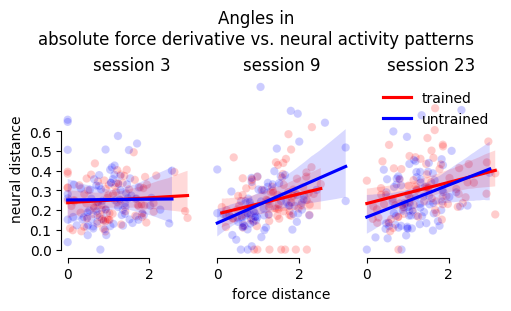

In [164]:
# neural against absolute force derivative angles in M1

metric = 'der'

force_m = force[force.chord.isin(hue_order) & (force.metric == metric)]

data = pd.merge(force_m, neural_r, on=['sn', 'session', 'pair', 'chord'], suffixes=('_force', '_neural'))

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5, 3), constrained_layout=True)

for s, sess in enumerate(gl.sessions):
    ax     = axs[s]
    data_s = data[data.session == sess]

    sb.scatterplot(data=data_s, ax=ax, x='theta_force', y='theta_neural',
                   hue='chord', hue_order=hue_order, palette=palette, legend=False, alpha=.2)
    sb.regplot(data=data_s[data_s.chord=='trained'], ax=ax, x='theta_force', y='theta_neural', scatter=False, units='sn', color=palette[0], label='trained')
    sb.regplot(data=data_s[data_s.chord=='untrained'], ax=ax, x='theta_force', y='theta_neural', scatter=False, units='sn', color=palette[1], label='untrained')

    ax.set_title(f'session {sess}')
    ax.set_xlabel(None)
    ax.set_ylabel('neural distance' if s == 0 else None)
    ax.tick_params(left=s==0)
    sb.despine(ax=ax, left=s>0, trim=True)

axs[-1].legend(frameon=False, loc='upper right')
axs[1].set_xlabel('force distance')
fig.suptitle('Angles in\nabsolute force derivative vs. neural activity patterns')

plt.show()

In [165]:
# regress the neural distances and angles on the force ones within each subject, force metric and region, and keep the residuals

metrics = ('abs', 'der', 'der_peak')

rois    = gl.rois[atlas]
force_m = force[force.metric.isin(metrics)]

data = pd.merge(force_m, neural, on=['sn', 'session', 'pair', 'chord'], suffixes=('_force', '_neural'))

data[['crossnobis_res', 'theta_res']] = np.nan
for (sn, metric, hem, roi), idx in data.groupby(['sn', 'metric', 'Hem', 'roi']).groups.items():
    data_s = data.loc[idx]
    for meas in ('crossnobis', 'theta'):
        X = np.c_[data_s[f'{meas}_force'].to_numpy(), np.ones(data_s.shape[0])]
        Y = data_s[f'{meas}_neural'].to_numpy()
        B = np.linalg.pinv(X) @ Y

        data.loc[idx, f'{meas}_res'] = Y - X @ B

res_chord_sess = data.groupby(['sn', 'metric', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

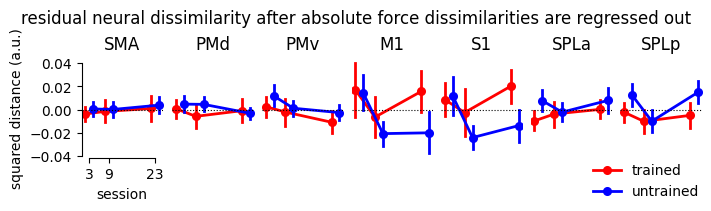

In [166]:
# residual neural distances with absolute force regressed out
metric = 'abs'

res_r = res_chord_sess[(res_chord_sess.Hem == H) & (res_chord_sess.metric == metric)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, res_r, rois, y='crossnobis_res', x='session',
             hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False)
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')
axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('residual neural dissimilarity after absolute force dissimilarities are regressed out')

plt.show()

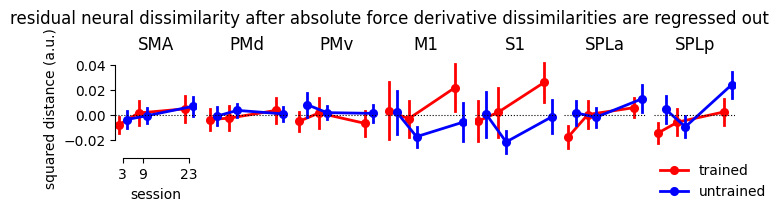

In [167]:
# residual neural distances with the absolute force derivative regressed out

metric = 'der'

res_r = res_chord_sess[(res_chord_sess.Hem == H) & (res_chord_sess.metric == metric)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, res_r, rois, y='crossnobis_res', x='session',
             hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False)
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')
axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('residual neural dissimilarity after absolute force derivative dissimilarities are regressed out')

plt.show()

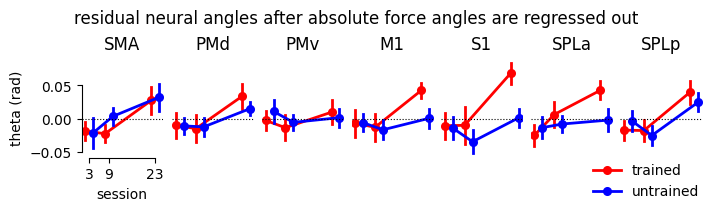

In [ ]:
# residual neural angles with absolute force regressed out

metric = 'abs'

res_r = res_chord_sess[(res_chord_sess.Hem == H) & (res_chord_sess.metric == metric)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, res_r, rois, y='theta_res', x='session',
             hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False)
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')
axs[0].set_ylabel('theta (rad)')

fig.suptitle('residual neural angles after absolute force angles are regressed out')

plt.show()

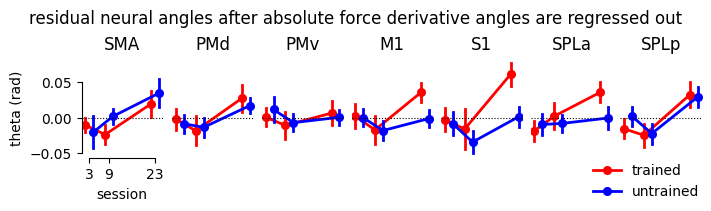

In [169]:
# residual neural angles with the absolute force derivative regressed out

metric = 'der'

res_r = res_chord_sess[(res_chord_sess.Hem == H) & (res_chord_sess.metric == metric)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, res_r, rois, y='theta_res', x='session',
             hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False)
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')
axs[0].set_ylabel('theta (rad)')

fig.suptitle('residual neural angles after absolute force derivative angles are regressed out')

plt.show()